 # Deep Learning Regression for House Price Prediction (King County)

### Introduction

In this notebook, we build a deep learning regression model to predict house prices using the King County housing dataset.

The dataset contains over 21,000 real estate records with features such as square footage, location, number of bedrooms, and property condition. This makes it a classic structured data problem where the goal is to estimate continuous house prices.

We develop a fully connected neural network (Dense layers) using TensorFlow/Keras to learn complex relationships between features. The workflow includes data preprocessing, feature engineering (including date transformation), model building, training, and evaluation.

The model demonstrates strong predictive performance, achieving a high R² score, which highlights the effectiveness of deep learning for regression tasks on tabular data.

This project is part of my machine learning and deep learning portfolio, focusing on building end-to-end solutions using real-world datasets.

<div align='center'>
<img src='https://upload.wikimedia.org/wikipedia/commons/thumb/b/bc/Seattle_-_King_County_Courthouse_and_King_County_Administration_Building_01.jpg/960px-Seattle_-_King_County_Courthouse_and_King_County_Administration_Building_01.jpg' width="600">
</div>

## Import Libraries

In [2]:
import pandas as pd
pd.set_option('display.max_columns',55)

import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

## Read Data

In [3]:
df=pd.read_csv('/kaggle/input/datasets/kamakshisoni/kchousedatanan/kc_house_data_NaN.csv')

## EDA

In [4]:
df.head()

,Unnamed: 0,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,0,7129300520,20141013T000000,221900.0,3.0,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,1,6414100192,20141209T000000,538000.0,3.0,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,2,5631500400,20150225T000000,180000.0,2.0,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,3,2487200875,20141209T000000,604000.0,4.0,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,4,1954400510,20150218T000000,510000.0,3.0,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [5]:
df.tail()

,Unnamed: 0,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
21608,21608,263000018,20140521T000000,360000.0,3.0,2.50,1530,1131,3.0,0,0,3,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,21609,6600060120,20150223T000000,400000.0,4.0,2.50,2310,5813,2.0,0,0,3,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,21610,1523300141,20140623T000000,402101.0,2.0,0.75,1020,1350,2.0,0,0,3,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,21611,291310100,20150116T000000,400000.0,3.0,2.50,1600,2388,2.0,0,0,3,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287
21612,21612,1523300157,20141015T000000,325000.0,2.0,0.75,1020,1076,2.0,0,0,3,7,1020,0,2008,0,98144,47.5941,-122.299,1020,1357


In [6]:
df.shape

(21613, 22)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     21613 non-null  int64  
 1   id             21613 non-null  int64  
 2   date           21613 non-null  object 
 3   price          21613 non-null  float64
 4   bedrooms       21600 non-null  float64
 5   bathrooms      21603 non-null  float64
 6   sqft_living    21613 non-null  int64  
 7   sqft_lot       21613 non-null  int64  
 8   floors         21613 non-null  float64
 9   waterfront     21613 non-null  int64  
 10  view           21613 non-null  int64  
 11  condition      21613 non-null  int64  
 12  grade          21613 non-null  int64  
 13  sqft_above     21613 non-null  int64  
 14  sqft_basement  21613 non-null  int64  
 15  yr_built       21613 non-null  int64  
 16  yr_renovated   21613 non-null  int64  
 17  zipcode        21613 non-null  int64  
 18  lat   

In [8]:
df.describe()

,Unnamed: 0,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,21613.00000,2.161300e+04,2.161300e+04,21600.000000,21603.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,10806.00000,4.580302e+09,5.400881e+05,3.372870,2.115736,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,6239.28002,2.876566e+09,3.671272e+05,0.926657,0.768996,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,0.00000,1.000102e+06,7.500000e+04,1.000000,0.500000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,5403.00000,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,10806.00000,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,16209.00000,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,21612.00000,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [9]:
df.isnull().sum()  

Unnamed: 0        0
id                0
date              0
price             0
bedrooms         13
bathrooms        10
sqft_living       0
sqft_lot          0
floors            0
waterfront        0
view              0
condition         0
grade             0
sqft_above        0
sqft_basement     0
yr_built          0
yr_renovated      0
zipcode           0
lat               0
long              0
sqft_living15     0
sqft_lot15        0
dtype: int64

In [10]:
df['bedrooms'].fillna(df['bedrooms'].mean(), inplace=True)
df['bathrooms'].fillna(df['bathrooms'].mean(), inplace=True)

In [11]:
df.corr(numeric_only=True)

,Unnamed: 0,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
Unnamed: 0,1.000000,0.006718,0.027372,0.010306,0.106989,0.044717,-0.026877,0.179138,-0.007611,-0.013751,-0.095419,0.082050,0.071958,-0.041841,0.199549,-0.025601,-0.002199,0.000701,0.008649,0.026647,-0.029827
id,0.006718,1.000000,-0.016762,0.001331,0.005233,-0.012258,-0.132109,0.018525,-0.002721,0.011592,-0.023783,0.008130,-0.010842,-0.005151,0.021380,-0.016907,-0.008224,-0.001891,0.020799,-0.002901,-0.138798
price,0.027372,-0.016762,1.000000,0.308797,0.525738,0.702035,0.089661,0.256794,0.266369,0.397293,0.036362,0.667434,0.605567,0.323816,0.054012,0.126434,-0.053203,0.307003,0.021626,0.585379,0.082447
bedrooms,0.010306,0.001331,0.308797,1.000000,0.514194,0.578077,0.032307,0.178022,-0.006800,0.080058,0.026690,0.356589,0.479286,0.302856,0.155749,0.018456,-0.153736,-0.009735,0.130978,0.393356,0.030430
bathrooms,0.106989,0.005233,0.525738,0.514194,1.000000,0.755371,0.087929,0.502132,0.063744,0.188341,-0.126197,0.664676,0.686309,0.283428,0.506913,0.050560,-0.204819,0.024246,0.224922,0.569467,0.087539
sqft_living,0.044717,-0.012258,0.702035,0.578077,0.755371,1.000000,0.172826,0.353949,0.103818,0.284611,-0.058753,0.762704,0.876597,0.435043,0.318049,0.055363,-0.199430,0.052529,0.240223,0.756420,0.183286
sqft_lot,-0.026877,-0.132109,0.089661,0.032307,0.087929,0.172826,1.000000,-0.005201,0.021604,0.074710,-0.008958,0.113621,0.183512,0.015286,0.053080,0.007644,-0.129574,-0.085683,0.229521,0.144608,0.718557
floors,0.179138,0.018525,0.256794,0.178022,0.502132,0.353949,-0.005201,1.000000,0.023698,0.029444,-0.263768,0.458183,0.523885,-0.245705,0.489319,0.006338,-0.059121,0.049614,0.125419,0.279885,-0.011269
waterfront,-0.007611,-0.002721,0.266369,-0.006800,0.063744,0.103818,0.021604,0.023698,1.000000,0.401857,0.016653,0.082775,0.072075,0.080588,-0.026161,0.092885,0.030285,-0.014274,-0.041910,0.086463,0.030703
view,-0.013751,0.011592,0.397293,0.080058,0.188341,0.284611,0.074710,0.029444,0.401857,1.000000,0.045990,0.251321,0.167649,0.276947,-0.053440,0.103917,0.084827,0.006157,-0.078400,0.280439,0.072575


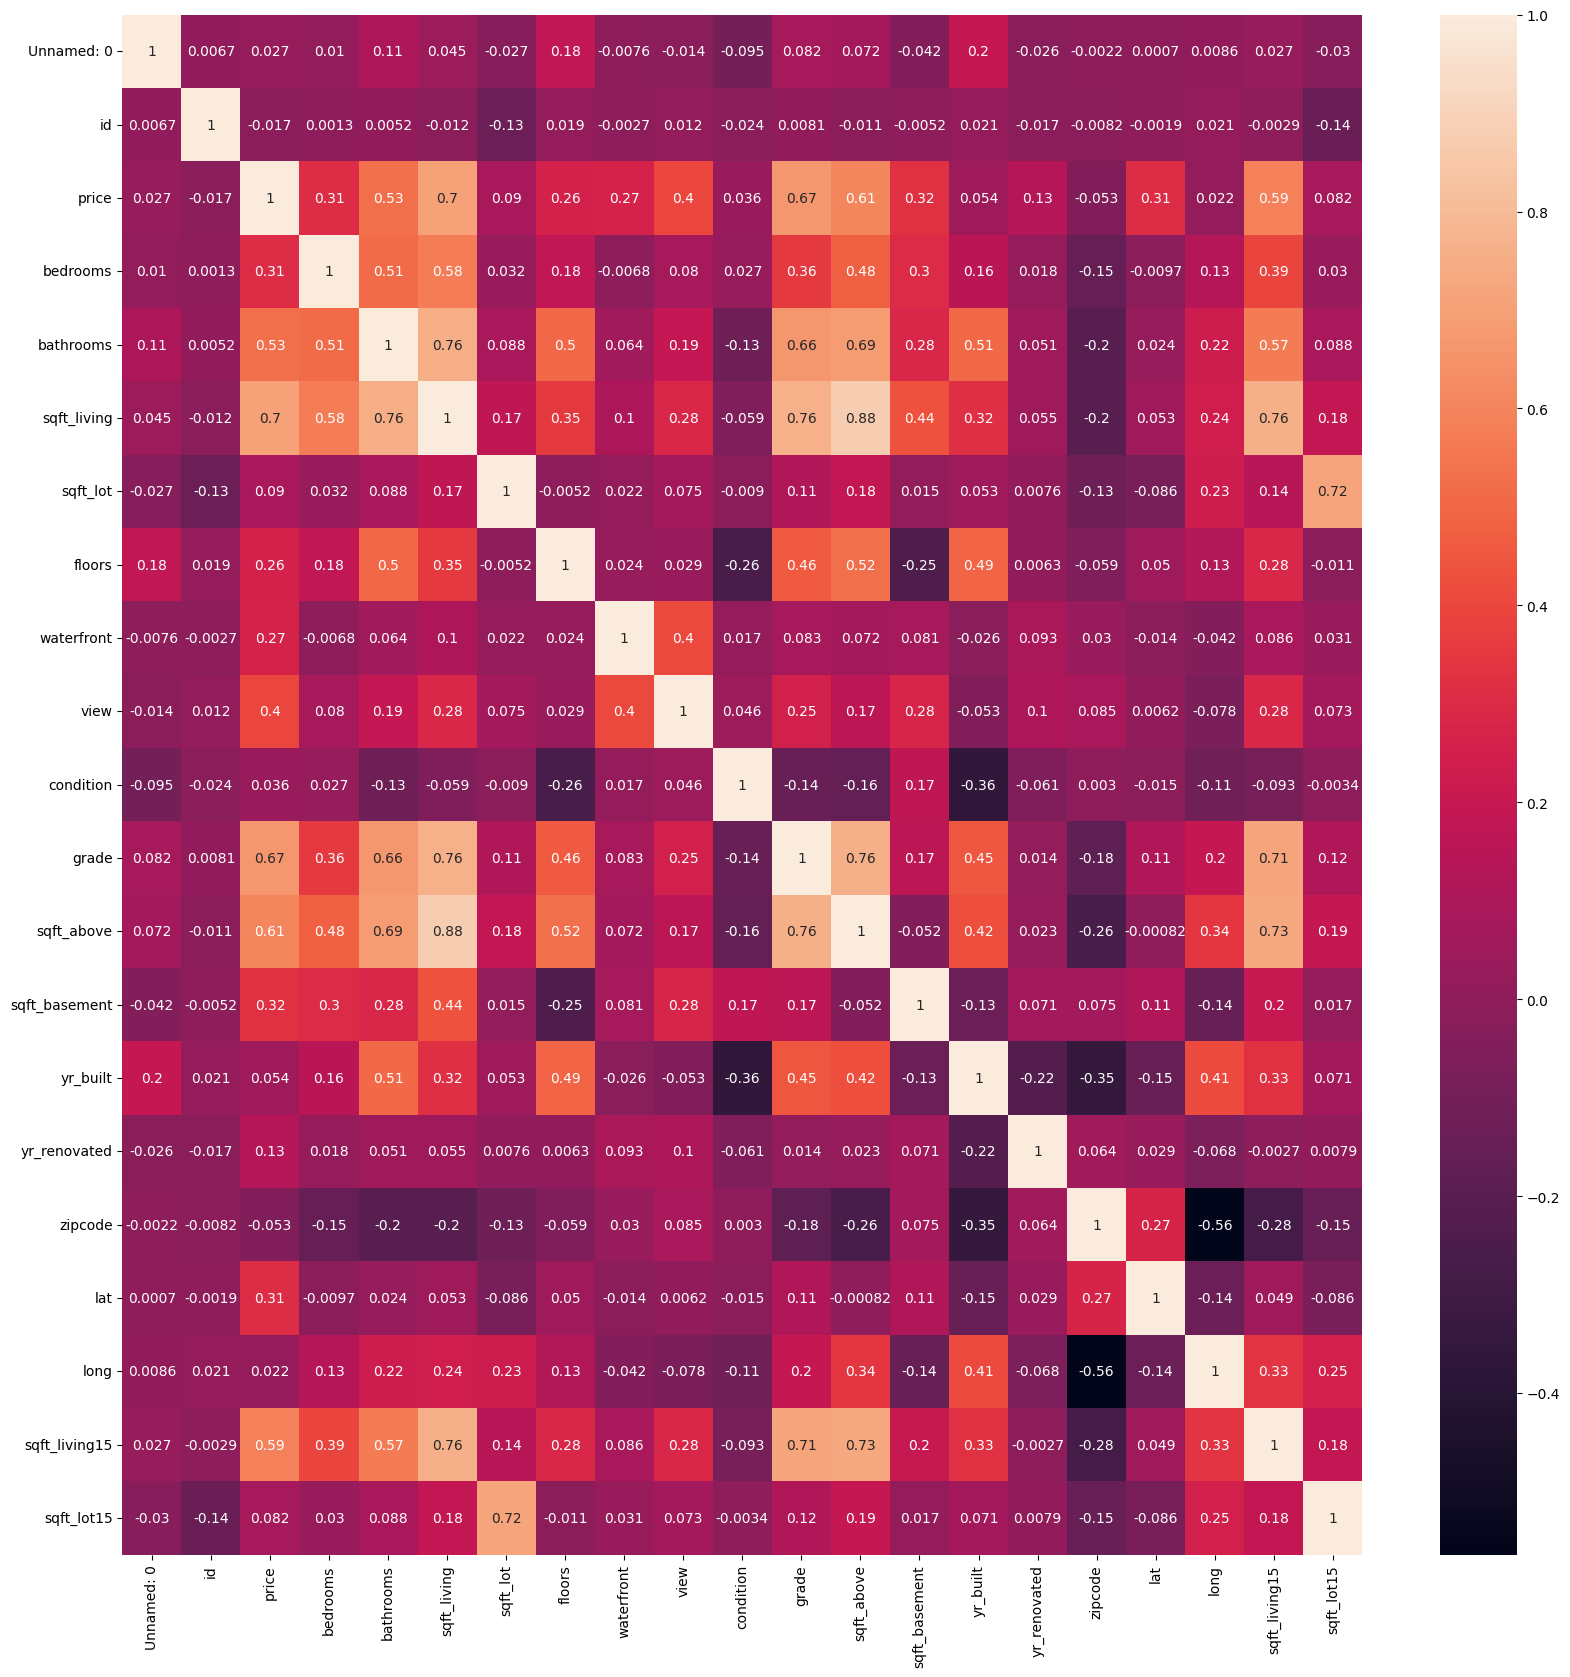

In [12]:
plt.figure(figsize=(20,20))
sns.heatmap(df.corr(numeric_only=True), annot=True);

In [13]:
abs(df.corr(numeric_only=True)['price'].sort_values(ascending=False)) #siraladik

price            1.000000
sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585379
bathrooms        0.525738
view             0.397293
sqft_basement    0.323816
bedrooms         0.308797
lat              0.307003
waterfront       0.266369
floors           0.256794
yr_renovated     0.126434
sqft_lot         0.089661
sqft_lot15       0.082447
yr_built         0.054012
condition        0.036362
Unnamed: 0       0.027372
long             0.021626
id               0.016762
zipcode          0.053203
Name: price, dtype: float64

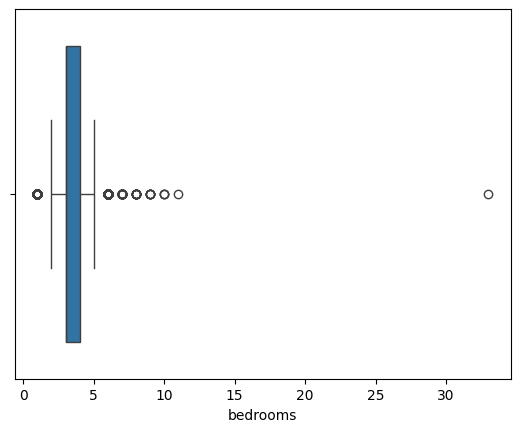

In [14]:
sns.boxplot(x=df['bedrooms']);
# Data points that are 3 standard deviations away from the mean are considered outliers.

In [15]:
df['bedrooms'].mean()+3*df['bedrooms'].std() # outlier 

np.float64(6.15200422253144)

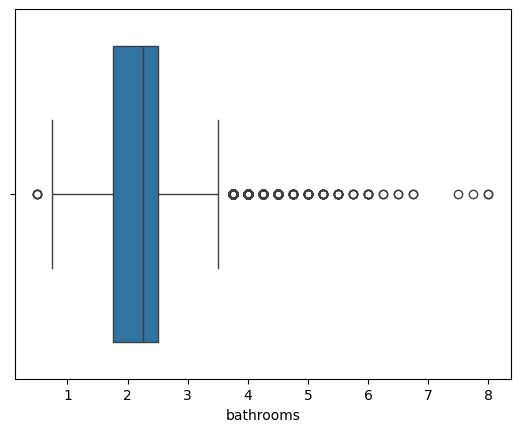

In [16]:
sns.boxplot(x=df['bathrooms']);

In [17]:
df[df['bedrooms']>30] 

,Unnamed: 0,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
15870,15870,2402100895,20140625T000000,640000.0,33.0,1.75,1620,6000,1.0,0,0,5,7,1040,580,1947,0,98103,47.6878,-122.331,1330,4700


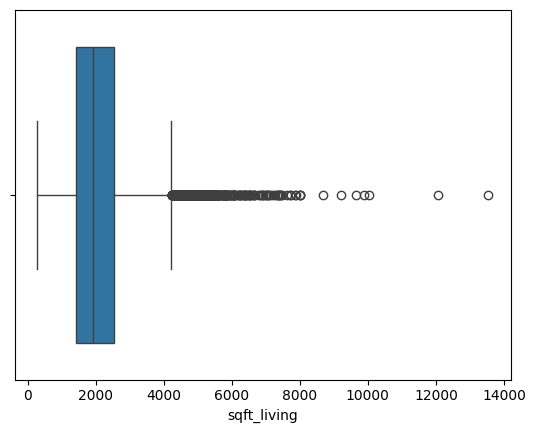

In [18]:
sns.boxplot(x=df['sqft_living']);

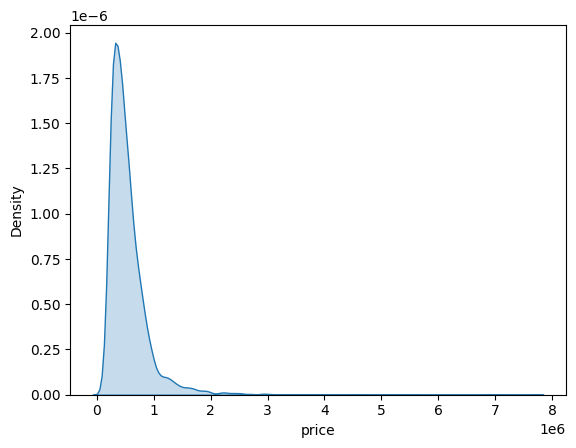

In [22]:
sns.kdeplot(x=df['price'],fill=True);

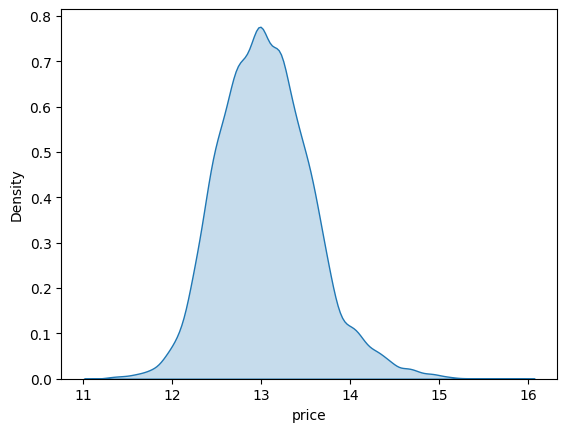

In [23]:
sns.kdeplot(x=np.log(df['price']),fill=True);

In [24]:
outliers=df.quantile(q=.97,numeric_only=True)

In [25]:
df=df[(df['price']<outliers['price'])]
df=df[(df['bedrooms']<outliers['bedrooms'])]
df=df[(df['bathrooms']<outliers['bathrooms'])]
df=df[(df['sqft_living']<outliers['sqft_living'])]

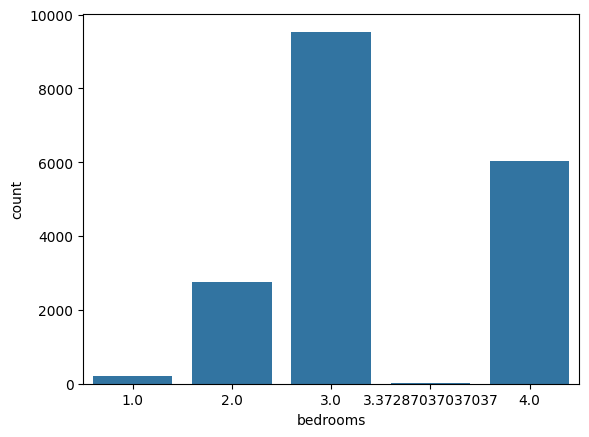

In [26]:
sns.countplot(x=df['bedrooms']);

## Feature Engineering 

In [27]:
df['zipcode']=df['zipcode'].astype('object') 
# df['zipcode']=df['zipcode'].astype('category')
# Although they were numeric, we converted them into categorical (text) data.

In [28]:
df['zipcode']

0        98178
1        98125
2        98028
3        98136
4        98074
         ...  
21608    98103
21609    98146
21610    98144
21611    98027
21612    98144
Name: zipcode, Length: 18519, dtype: object

In [29]:
# We increase the importance of these features by assigning them higher weight in the model.
df['bedrooms']=df['bedrooms']**2
df['bathrooms']=df['bathrooms']**2
df['sqft_living']=df['sqft_living']**2

In [30]:
import datetime

In [31]:
datetime.datetime.now().year

2026

In [32]:
df['age']=datetime.datetime.now().year-df['yr_built'] # We are creating the age of the house as a new feature.

In [33]:
df['yr_renovated'] = np.where(df['yr_renovated'] > 1, 1, 0)  # 1 if renovated, 0 otherwise
df['sqft_basement'] = np.where(df['sqft_basement'] > 1, 1, 0)  # 1 if basement exists, 0 otherwise

In [34]:
df.columns

Index(['Unnamed: 0', 'id', 'date', 'price', 'bedrooms', 'bathrooms',
       'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition',
       'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated',
       'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'age'],
      dtype='object')

In [35]:
x=df.drop(['id','date','lat','long','price','yr_built'],axis=1) 
y=df[['price']]

In [36]:
x=pd.get_dummies(x,drop_first=True)

In [37]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [38]:
x=scaler.fit_transform(x)

In [39]:
#from sklearn.preprocessing import MinMaxScaler
#x=MinMaxScaler().fit_transform(x)

In [40]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20, random_state=42)

In [42]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [43]:
model=Sequential()
model.add(Dense(80, activation='relu'))
model.add(Dense(120, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(30, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1)) # regression so no sigmoid 


model.compile(loss='mean_squared_error', optimizer='adam')

2026-04-19 10:22:07.935156: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [49]:
history=model.fit(x,y,batch_size =32, validation_split=0.10,verbose=1, epochs=500)

Epoch 1/500
521/521 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 4678156800.0000 - val_loss: 5929926656.0000
Epoch 2/500
521/521 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4530491904.0000 - val_loss: 5957175808.0000
Epoch 3/500
521/521 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4794806784.0000 - val_loss: 5978570240.0000
Epoch 4/500
521/521 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4514832384.0000 - val_loss: 6106686464.0000
Epoch 5/500
521/521 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4697290752.0000 - val_loss: 6003347456.0000
Epoch 6/500
521/521 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4638358016.0000 - val_loss: 6073354240.0000
Epoch 7/500
521/521 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4591814656.0000 - val_loss: 5823648256.0000
Epoch 8/500
521/521 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4663951872.0000 - val_loss: 5928545280.0000
Epoch 9/500
521/521 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4437164544.0000 - val_loss: 6048150528.0000
Epoch 10/500
521/521 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step -

In [50]:
tahmin=model.predict(x_test)

116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [51]:
from sklearn.metrics import r2_score, mean_squared_error

In [52]:
r2_score(y_test,tahmin)

0.923461377620697

## Conclusion

In this project, we developed a deep learning model to predict house prices using the King County housing dataset.

The neural network successfully learned complex patterns in the data and achieved strong performance with an R² score of approximately 0.92. This demonstrates the capability of deep learning models to handle regression problems on structured, real-world datasets.

Feature engineering, including transforming date information and handling missing values, played an important role in improving model performance. Despite using a relatively simple fully connected architecture, the model was able to capture meaningful relationships between features such as living area, location, and property condition.

Overall, this project highlights how deep learning can be effectively applied to real estate price prediction and provides a strong foundation for more advanced regression modeling tasks.